In [7]:
%pip install gym
%pip install numpy
%pip install torch
%pip install optuna
%pip install plotly
%pip install nbformat

def reload_module(m):
    import importlib
    importlib.reload(m)

import numpy as np
import torch
import random
from collections import deque
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import uts
from consts import *
import optuna
import optuna.visualization as vis
import consts
from te import TradingEnv

# avoid caching
reload_module(uts) 
reload_module(consts) 

utils = uts.Utilities(is_test=consts.IS_TEST, test_num=consts.TEST_NUM)
etf_dfs = utils.get_dataframes('data/ETFs')
stock_dfs = utils.get_dataframes('data/Stocks')

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


[I 2025-05-25 22:44:13,370] A new study created in memory with name: no-name-7292c722-71ea-4478-9842-c4cbee3a6922
[I 2025-05-25 22:44:22,520] Trial 0 finished with value: 2.3283064365386963e-10 and parameters: {'gamma': 0.9679256776770393, 'lr': 0.009060452715722148, 'epsilon_decay': 0.9539958325538697, 'hidden_dim': 52, 'batch_size': 64, 'memory': 3683}. Best is trial 0 with value: 2.3283064365386963e-10.
[I 2025-05-25 22:44:30,013] Trial 1 finished with value: 3.8805107275644936e-11 and parameters: {'gamma': 0.9838796628193709, 'lr': 0.0021447053323247656, 'epsilon_decay': 0.9210031301086408, 'hidden_dim': 54, 'batch_size': 32, 'memory': 2189}. Best is trial 0 with value: 2.3283064365386963e-10.
[I 2025-05-25 22:44:38,266] Trial 2 finished with value: -3.8805107275644936e-11 and parameters: {'gamma': 0.9847459826495353, 'lr': 0.0066411342070409095, 'epsilon_decay': 0.9544327858292324, 'hidden_dim': 35, 'batch_size': 64, 'memory': 3930}. Best is trial 0 with value: 2.3283064365386963e

Best trial:
{'gamma': 0.863223866724038, 'lr': 0.0003500610721284508, 'epsilon_decay': 0.9446127835608885, 'hidden_dim': 45, 'batch_size': 64, 'memory': 4460}


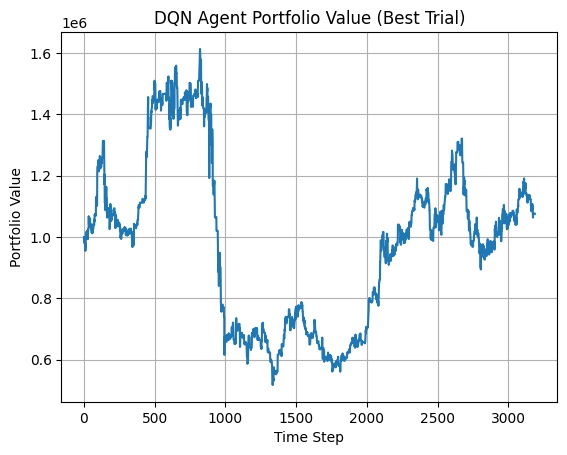

[I 2025-05-25 22:45:35,305] A new study created in memory with name: no-name-79163c1e-d792-4749-af23-3d21a70ba483
[I 2025-05-25 22:45:42,370] Trial 0 finished with value: 3.8805107275644936e-11 and parameters: {'gamma': 0.9445191640542819, 'lr': 0.0017289433574283197, 'epsilon_decay': 0.9670040927367965, 'hidden_dim': 57, 'batch_size': 32, 'memory': 3981}. Best is trial 0 with value: 3.8805107275644936e-11.
[I 2025-05-25 22:45:49,550] Trial 1 finished with value: -2.3283064365386963e-10 and parameters: {'gamma': 0.9498902879896981, 'lr': 0.00024451135436753867, 'epsilon_decay': 0.9941153373920951, 'hidden_dim': 54, 'batch_size': 32, 'memory': 2709}. Best is trial 0 with value: 3.8805107275644936e-11.
[I 2025-05-25 22:45:56,839] Trial 2 finished with value: 7.761021455128987e-11 and parameters: {'gamma': 0.9818838389428811, 'lr': 0.0016996475468257796, 'epsilon_decay': 0.9843697581395316, 'hidden_dim': 60, 'batch_size': 32, 'memory': 4667}. Best is trial 2 with value: 7.761021455128987e

Best trial:
{'gamma': 0.9818838389428811, 'lr': 0.0016996475468257796, 'epsilon_decay': 0.9843697581395316, 'hidden_dim': 60, 'batch_size': 32, 'memory': 4667}


Error during plotting


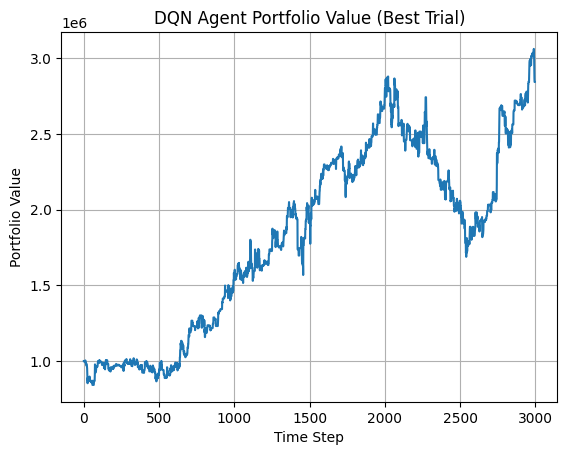

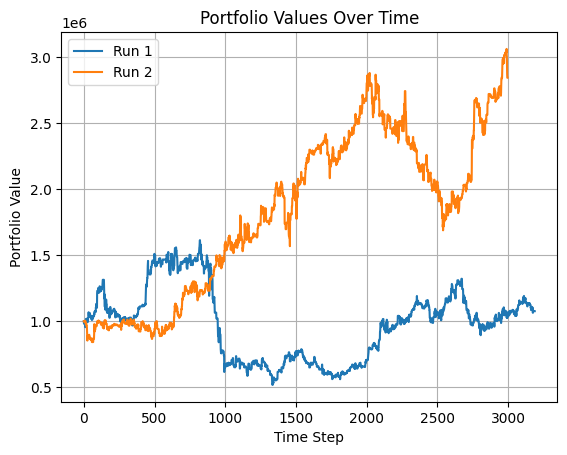

In [8]:
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

class DQNAgent:
    def __init__(self, state_size, action_size, hidden_dim, gamma, lr, epsilon_decay, batch_size, memory):
        self.model = DQN(state_size, action_size, hidden_dim)
        self.target_model = DQN(state_size, action_size, hidden_dim)
        self.target_model.load_state_dict(self.model.state_dict())
        self.memory = deque(maxlen=memory)
        self.gamma = gamma
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = epsilon_decay
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.batch_size = batch_size

    def act(self, state):
        if np.random.rand() < self.epsilon:
            return random.choice([0, 1, 2])  # Hold, Buy, Sell
        state = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = self.model(state)
        return torch.argmax(q_values).item()

    def remember(self, s, a, r, s2, done):
        self.memory.append((s, a, r, s2, done))

    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        batch = random.sample(self.memory, self.batch_size)
        s, a, r, s2, d = zip(*batch)
        s = torch.FloatTensor(s)
        a = torch.LongTensor(a).unsqueeze(1)
        r = torch.FloatTensor(r).unsqueeze(1)
        s2 = torch.FloatTensor(s2)
        d = torch.FloatTensor(d).unsqueeze(1)

        q = self.model(s).gather(1, a)
        q_next = self.target_model(s2).max(1)[0].unsqueeze(1)
        q_target = r + self.gamma * q_next * (1 - d)

        loss = nn.MSELoss()(q, q_target.detach())
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def update_target(self):
        self.target_model.load_state_dict(self.model.state_dict())

class DQNObjective:
    def __init__(self, env):
        self.env = env

    def __call__(self, trial):
        return optimize_dqn(trial, self.env)


def optimize_dqn(trial, env):
    gamma = trial.suggest_float('gamma', 0.85, 0.99)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    epsilon_decay = trial.suggest_float('epsilon_decay', 0.9, 0.999)
    hidden_dim = trial.suggest_int('hidden_dim', 32, 64)
    batch_size = trial.suggest_categorical('batch_size', [32, 64])
    memory = trial.suggest_int('memory', 2000, 5000)

    agent = DQNAgent(state_size=env.window_size, action_size=3,
                     hidden_dim=hidden_dim, gamma=gamma, lr=lr,
                     epsilon_decay=epsilon_decay, batch_size=batch_size, memory=memory)

    rewards = []

    for ep in range(consts.EPISODES):
        state = env.reset()
        total_reward = 0
        while True:
            action = agent.act(state)
            next_state, reward, done, _ = env.step(action)
            agent.remember(state, action, reward, next_state, done)
            agent.replay()
            state = next_state
            total_reward += reward
            if done:
                break
        agent.update_target()
        rewards.append(total_reward)

    return np.mean(rewards[-3:])

def plot_perf(best_params, env):
    agent = DQNAgent(
        state_size=env.window_size,
        action_size=3,
        hidden_dim=best_params['hidden_dim'],
        gamma=best_params['gamma'],
        lr=best_params['lr'],
        epsilon_decay=best_params['epsilon_decay'],
        batch_size=best_params['batch_size'],
        memory=best_params['memory']
    )

    portfolio_values = []

    state = env.reset()
    while True:
        action = agent.act(state)
        next_state, reward, done, _ = env.step(action)
        portfolio_values.append(env.get_value())
        state = next_state
        if done:
            break
    

    plt.plot(portfolio_values)
    plt.title("DQN Agent Portfolio Value (Best Trial)")
    plt.xlabel("Time Step")
    plt.ylabel("Portfolio Value")
    plt.grid(True)
    plt.show()

    return portfolio_values

def plot_dqn_res():
    portfolio_vals_arr = []
    for df in stock_dfs[:consts.RL_LIMIT]:
        prices = df['Close'].values
        env = TradingEnv(prices)
        study = optuna.create_study(direction='maximize')
        study.optimize(DQNObjective(env=env), n_trials=10)

        best_params = study.best_trial.params

        print("Best trial:")
        print(study.best_trial.params)
        
        try:
            fig = vis.plot_optimization_history(study)
            fig.show()

            fig2 = vis.plot_param_importances(study)
            fig2.show()
        except Exception:
            # since the number of trials and episodes are relatively small, optuna sometimes returns an error
            print("Error during plotting")

        pv = plot_perf(best_params, env)
        portfolio_vals_arr.append(pv)

    for i, portfolio_values in enumerate(portfolio_vals_arr):
        plt.plot(portfolio_values, label=f'Run {i+1}')

    plt.title('Portfolio Values Over Time')
    plt.xlabel('Time Step')
    plt.ylabel('Portfolio Value')
    plt.legend()
    plt.grid(True)
    plt.show() 

plot_dqn_res()